[Colab] Please upload the Excel file. Required columns: element, a, b. Optional column: kappa.


Saving endmembers_22elems.xlsx to endmembers_22elems (1).xlsx
[Colab] Received: endmembers_22elems (1).xlsx -> saved as: endmembers_22elems.xlsx
[Info] Output directory: /content/mixing22_colab_upload_no_visc_guard


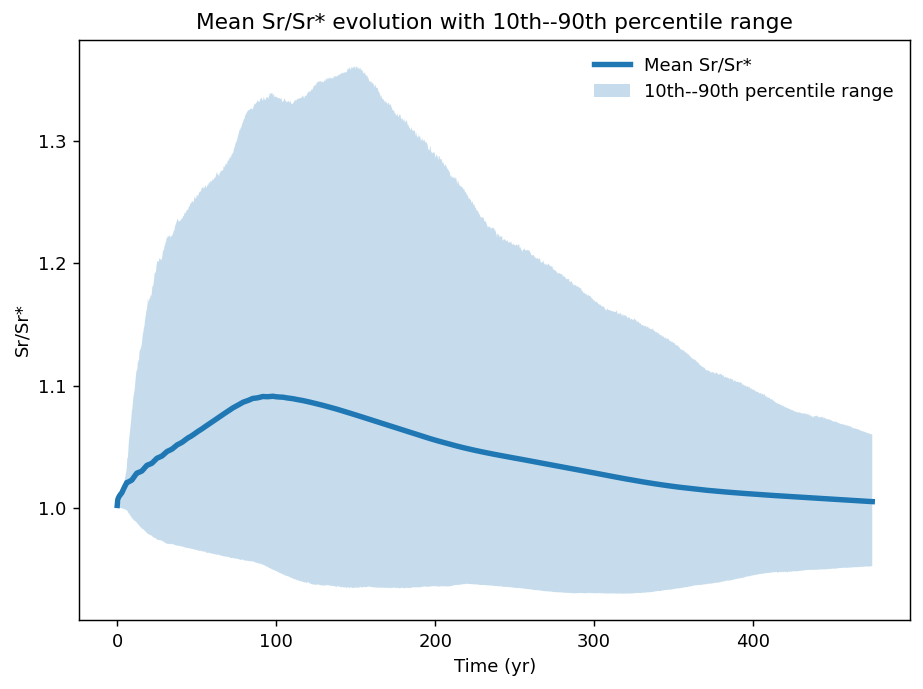

[Saved] mixing22_colab_upload_no_visc_guard/Mean_SrSrStar_vs_time_10_90_percentile.png


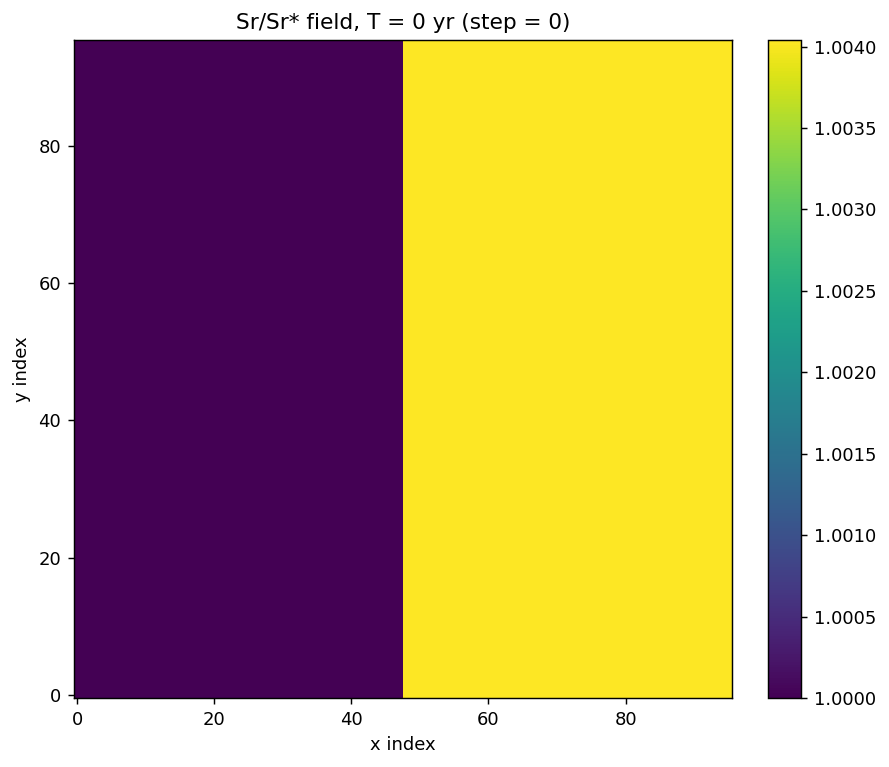

[Saved] mixing22_colab_upload_no_visc_guard/SrSrStar_field_t0.png


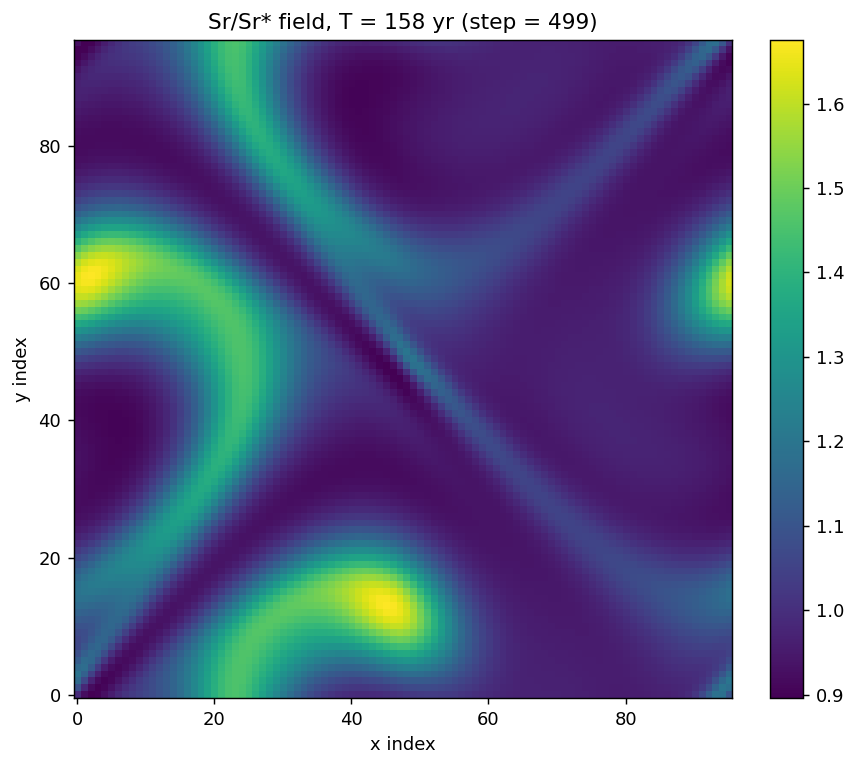

[Saved] mixing22_colab_upload_no_visc_guard/SrSrStar_field_t499.png


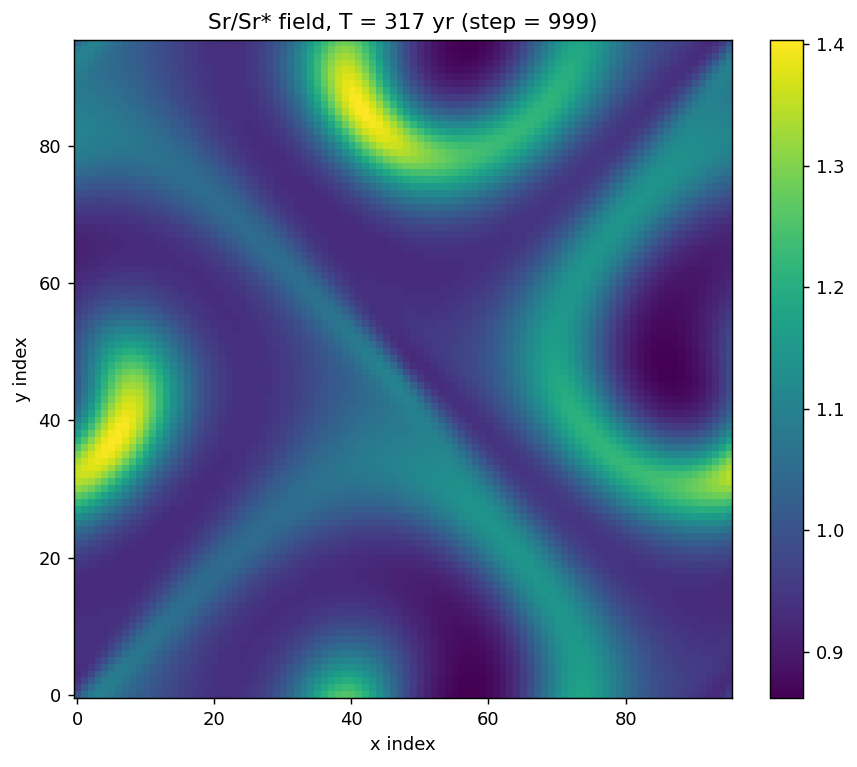

[Saved] mixing22_colab_upload_no_visc_guard/SrSrStar_field_t999.png


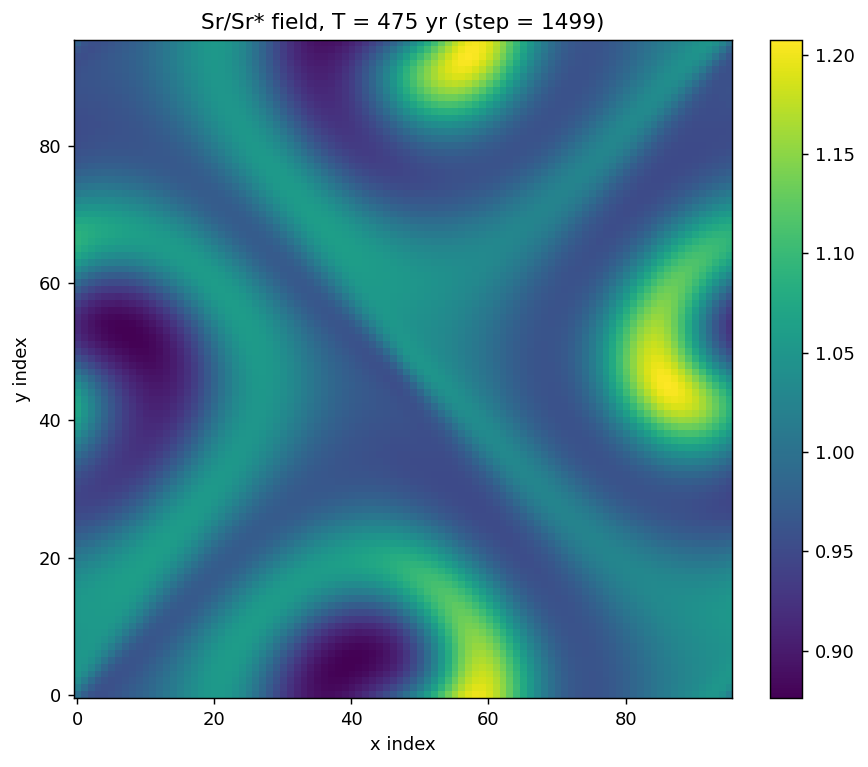

[Saved] mixing22_colab_upload_no_visc_guard/SrSrStar_field_t1499.png


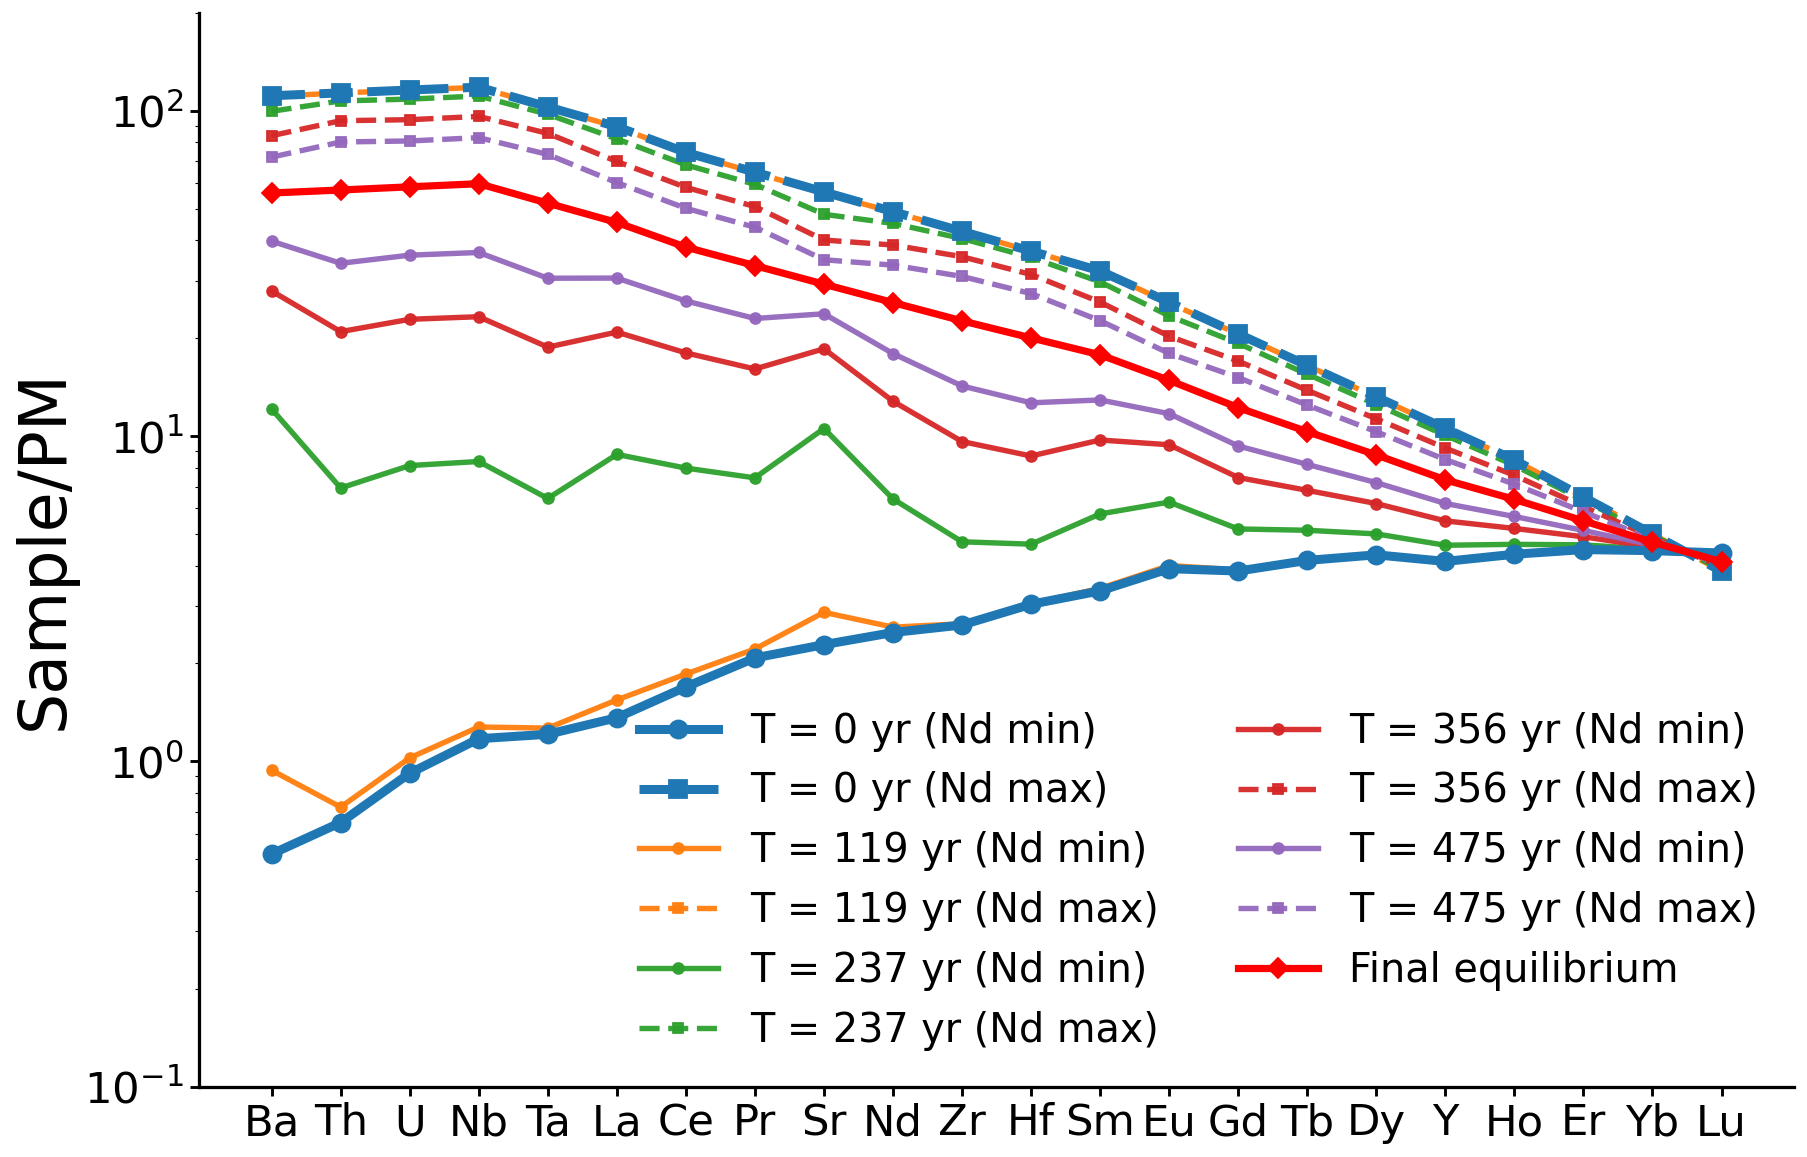

[Saved] mixing22_colab_upload_no_visc_guard/Elem22_profile_SELECTED_TIMES_log.png


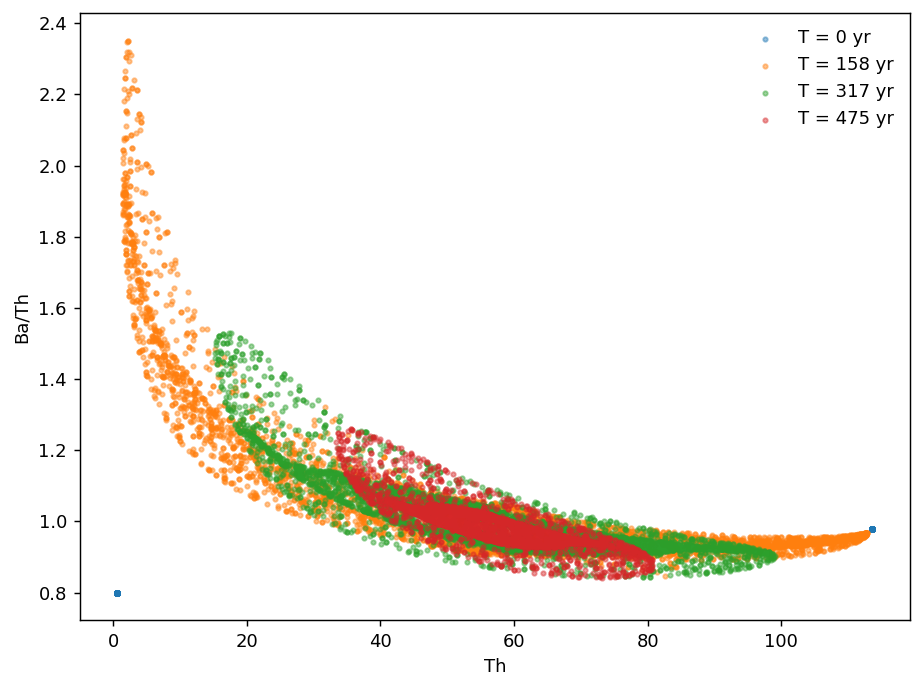

[Saved] mixing22_colab_upload_no_visc_guard/BaTh_vs_Th_DEFAULT4.png

[Done] All figures have been written to: /content/mixing22_colab_upload_no_visc_guard


In [5]:
"""
Supplementary Python code: 22-element 2-D advection--diffusion mixing model
================================================================================

Purpose
-------
This script simulates two-dimensional chaotic advection and diffusion between two
initial melt endmembers. The model tracks 22 trace-element concentration fields
on a periodic square domain. It is designed for geochemical mixing experiments
in which each element may have its own diffusion coefficient.

Input file
----------
The script is intended to be run in Google Colab. When executed, it opens a file
upload window and asks the user to upload an Excel file.

Recommended Excel file name:
    endmembers_22elems.xlsx

Required sheet name:
    endmembers_22elems

Required columns:
    element : element symbol or name, e.g., Ba, Th, U, Nb, Ta, La, Ce, Pr, Sr,
              Nd, Zr, Hf, Sm, Eu, Gd, Tb, Dy, Y, Ho, Er, Yb, Lu
    a       : concentration of each element in endmember A
    b       : concentration of each element in endmember B

Optional column:
    kappa   : element-specific diffusion coefficient in m^2/s

If the kappa column is absent, all elements use the default diffusion coefficient
specified in the configuration section.

Main outputs
------------
The script writes figures to the output directory defined by C.outdir:

1. Mean Sr/Sr* evolution through time with a 10th--90th percentile range.
   Here Sr/Sr* is calculated as Sr / sqrt(Pr * Nd).
2. Sr/Sr* spatial fields at four selected model times.
3. A 22-element concentration profile at selected model times. At each selected
   time, the script samples the grid cells with minimum and maximum Nd.
4. Ba/Th versus Th scatter plots at four selected model times.

Numerical method
----------------
The governing equation for each element is the two-dimensional advection--
diffusion equation:

    dC/dt + u dC/dx + v dC/dy = kappa (d^2C/dx^2 + d^2C/dy^2)

where C is concentration, u and v are velocity components, and kappa is the
tracer diffusion coefficient. The calculation uses operator splitting:

1. Advection step:
   A semi-Lagrangian back-tracing method is used. For each grid cell at the new
   time level, the previous position of the fluid parcel is traced backward over
   one time step. The previous concentration at that back-traced position is
   then estimated by bilinear interpolation.

2. Diffusion step:
   Explicit finite differences are used to approximate the two-dimensional
   Laplacian. Periodic boundary conditions are implemented using numpy.roll.

Boundary condition
------------------
The domain is periodic in both x and y directions. Material leaving one side of
the domain re-enters from the opposite side.


"""

# =============================================================================
# 1. Import required packages
# =============================================================================

import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter


# =============================================================================
# 2. Google Colab file upload
# =============================================================================
# This script is written for Google Colab. The block below opens a file upload
# window every time the script is run. The uploaded Excel file is renamed to the
# standard file name used later in the script.

try:
    from google.colab import files as _colab_files
except Exception as _e:
    raise RuntimeError(
        "This script is intended for Google Colab. "
        "Please run it in Colab to enable the file upload window."
    ) from _e

print("[Colab] Please upload the Excel file. Required columns: element, a, b. Optional column: kappa.")
_uploaded = _colab_files.upload()

if not _uploaded:
    raise FileNotFoundError("No file was uploaded.")

_excel_name = None
for _fn in _uploaded.keys():
    if str(_fn).lower().endswith(".xlsx"):
        _excel_name = _fn
        break

if _excel_name is None:
    raise ValueError("No .xlsx file was detected. Please upload an Excel file.")

EXCEL_PATH = "endmembers_22elems.xlsx"

# Rename the uploaded file to a fixed name. This makes the rest of the script
# independent of the original local file name.
if _excel_name != EXCEL_PATH:
    if os.path.exists(EXCEL_PATH):
        os.remove(EXCEL_PATH)
    os.rename(_excel_name, EXCEL_PATH)

print(f"[Colab] Received: {_excel_name} -> saved as: {EXCEL_PATH}")


# =============================================================================
# 3. Basic plotting settings
# =============================================================================
# These settings avoid common display problems in Colab and improve figure
# resolution. LaTeX rendering is disabled so that the script can run without a
# local LaTeX installation.

plt.rcParams["text.usetex"] = False
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 130


# =============================================================================
# 4. Model configuration
# =============================================================================

SHEET_NAME = "endmembers_22elems"


@dataclass
class CFG:
    """Container for all user-adjustable model parameters.

    Attributes
    ----------
    N : int
        Number of grid cells in both x and y directions. The total grid size is
        therefore N x N.
    L : float
        Physical length of the square model domain in meters.
    dt : float
        Time-step length in seconds.
    steps : int
        Number of time steps. The final model time is approximately
        steps * dt.
    A0 : float
        Characteristic velocity amplitude in m/s. Larger A0 produces stronger
        advection and more vigorous stirring.
    switch_period : int
        Number of time steps between switching the sine flow direction.
    kappa_default : float
        Default diffusion coefficient in m^2/s used for elements without a
        specified kappa value in the Excel file.
    outdir : str
        Directory in which output figures are saved.
    seconds_per_year : float
        Conversion factor from seconds to years.
    time_unit : str
        Time unit label used in figure axes.
    profile_years : tuple or None
        Optional user-defined profile times in years. If not None, these times
        override profile_steps.
    profile_steps : tuple, str, or None
        Steps used for the 22-element profile plot. If set to "AUTO5", five
        evenly spaced model times are selected automatically.
    """

    N: int = 96
    L: float = 10.0
    dt: float = 1.0e7
    steps: int = 1500  # Increase this value, e.g., to 6000, for longer runs.

    A0: float = 3e-9
    switch_period: int = 10

    kappa_default: float = 6e-11

    outdir: str = "mixing22_colab_upload_no_visc_guard"

    seconds_per_year: float = 365.25 * 86400.0
    time_unit: str = "yr"

    profile_years: tuple = None
    profile_steps: tuple = "AUTO5"


C = CFG()
os.makedirs(C.outdir, exist_ok=True)


# =============================================================================
# 5. Read the Excel input file
# =============================================================================

def read_elements_excel(path, sheet):

    df = pd.read_excel(path, sheet_name=sheet)

    # Standardize column names to lower case and remove accidental spaces.
    df.columns = [str(c).strip().lower() for c in df.columns]

    # The minimum required input is the element name and the two endmember
    # concentrations.
    for c in ("element", "a", "b"):
        if c not in df.columns:
            raise ValueError(f"Sheet '{sheet}' must contain the columns: element, a, b")

    df["element"] = df["element"].astype(str).str.strip()

    # This model version is designed for a 22-element profile. If a different
    # number of rows is needed, this check can be changed accordingly.
    if len(df) != 22:
        raise ValueError(f"Sheet '{sheet}' must have exactly 22 rows; currently it has {len(df)} rows.")

    elements = df["element"].tolist()
    concA_map = dict(zip(elements, df["a"].astype(float)))
    concB_map = dict(zip(elements, df["b"].astype(float)))

    if "kappa" in df.columns:
        kappa_map = dict(zip(elements, df["kappa"].astype(float)))
    else:
        kappa_map = {}

    # Sr, Pr, Nd, Ba, and Th are required because this script calculates
    # Sr/Sr* = Sr / sqrt(Pr * Nd) and plots Ba/Th--Th diagrams.
    lower_names = [e.lower() for e in elements]
    for required_element in ("sr", "pr", "nd", "ba", "th"):
        if required_element not in lower_names:
            raise ValueError("The input file must include Sr, Pr, Nd, Ba, and Th.")

    return elements, concA_map, concB_map, kappa_map


elements, concA_map, concB_map, kappa_map = read_elements_excel(EXCEL_PATH, SHEET_NAME)

# Preserve the original capitalization of required elements, while allowing the
# Excel file to use any capitalization, e.g., Sr or sr.
lower_to_name = {e.lower(): e for e in elements}
SR = lower_to_name["sr"]
PR = lower_to_name["pr"]
ND = lower_to_name["nd"]
BA = lower_to_name["ba"]
TH = lower_to_name["th"]


# =============================================================================
# 6. Construct the numerical grid
# =============================================================================

N, L, dt = C.N, C.L, C.dt

# Grid spacing in meters.
dx = L / N
dy = L / N

# Cell-centered coordinates. The first cell center is located at dx/2, not at 0.
x = (np.arange(N) + 0.5) * dx
y = (np.arange(N) + 0.5) * dy

# Two-dimensional coordinate arrays. Indexing="ij" means that the first axis is
# x and the second axis is y, consistent with array shape (N, N).
X, Y = np.meshgrid(x, y, indexing="ij")


def steps_to_years(s):
    """Convert a model step number to years."""

    return s * dt / C.seconds_per_year


def split_field(a, b, frac=0.5):

    F = np.zeros((N, N))
    F[X < frac * L] = a
    F[X >= frac * L] = b
    return F


# Concentration fields for all elements. Each dictionary value is a two-
# dimensional N x N array.
conc = {e: split_field(concA_map[e], concB_map[e]) for e in elements}


# =============================================================================
# 7. Numerical kernels: advection, diffusion, and velocity field
# =============================================================================

def advect(Cf, u, v, dt_local):

    # Back-traced physical coordinates. The modulo operation enforces periodic
    # boundaries in both directions.
    Xb = (X - u * dt_local) % L
    Yb = (Y - v * dt_local) % L

    # Convert physical coordinates to fractional array indices. The -0.5 term is
    # needed because the grid is cell-centered.
    xb = Xb / dx - 0.5
    yb = Yb / dy - 0.5

    # Lower-left integer index of the interpolation cell.
    i0 = np.floor(xb).astype(int) % N
    j0 = np.floor(yb).astype(int) % N

    # Upper-right neighboring index. Periodic wrapping is used at the boundary.
    i1 = (i0 + 1) % N
    j1 = (j0 + 1) % N

    # Fractional distances within the interpolation cell.
    sx = xb - np.floor(xb)
    sy = yb - np.floor(yb)

    # Four neighboring values used for bilinear interpolation.
    C00 = Cf[i0, j0]
    C10 = Cf[i1, j0]
    C01 = Cf[i0, j1]
    C11 = Cf[i1, j1]

    # Bilinear interpolation formula.
    return (
        (1 - sx) * (1 - sy) * C00
        + sx * (1 - sy) * C10
        + (1 - sx) * sy * C01
        + sx * sy * C11
    )


def diffuse(Cf, kappa, dt_local):

    Cxx = (np.roll(Cf, -1, axis=0) - 2 * Cf + np.roll(Cf, 1, axis=0)) / dx**2
    Cyy = (np.roll(Cf, -1, axis=1) - 2 * Cf + np.roll(Cf, 1, axis=1)) / dy**2

    return Cf + kappa * dt_local * (Cxx + Cyy)


def vel(t, amp):

    phase = (t // C.switch_period) % 2

    if phase == 0:
        u = amp * np.sin(2 * np.pi * (Y / L))
        v = np.zeros_like(u)
    else:
        u = np.zeros_like(X)
        v = amp * np.sin(2 * np.pi * (X / L))

    return u, v


# =============================================================================
# 8. Select snapshot and profile times
# =============================================================================

# Four default snapshot times used for the Sr/Sr* maps and Ba/Th--Th scatter plot.
BASE_STEPS = tuple(np.linspace(0, C.steps - 1, 4, dtype=int))


def yrs_to_steps(yrs):
    """Convert a sequence of times in years to model step numbers."""

    return tuple(
        np.clip(
            np.round(np.array(yrs) * C.seconds_per_year / dt).astype(int),
            0,
            C.steps - 1,
        )
    )


if C.profile_years is not None:
    PROFILE_STEPS = yrs_to_steps(C.profile_years)
elif C.profile_steps == "AUTO5":
    PROFILE_STEPS = tuple(np.linspace(0, C.steps - 1, 5, dtype=int))
elif C.profile_steps:
    PROFILE_STEPS = tuple(C.profile_steps)
else:
    PROFILE_STEPS = BASE_STEPS

# Save all snapshots that are required by any later plotting function.
ALL_SNAP_STEPS = tuple(sorted(set(BASE_STEPS) | set(PROFILE_STEPS)))


# =============================================================================
# 9. Main time loop
# =============================================================================

snaps = {}


def save_snap(t):

    snaps[t] = {e: conc[e].copy() for e in elements}


# Lists used to store Sr/Sr* statistics at every model time step.
srsrstar_time_steps = []
srsrstar_mean_list = []
srsrstar_p10_list = []
srsrstar_p90_list = []


def calc_srsrstar(Sr, Pr, Nd):
    """Calculate the true Sr anomaly, Sr/Sr*.

    In this script, Sr/Sr* is defined as:

        Sr/Sr* = Sr / sqrt(Pr * Nd)

    where Sr, Pr, and Nd should be on the same normalization basis, for example
    primitive-mantle-normalized concentrations. Safe division is used so that
    cells with non-positive Pr or Nd are assigned NaN.
    """

    denominator = np.sqrt(Pr * Nd)
    valid = (Pr > 0) & (Nd > 0) & np.isfinite(denominator) & (denominator > 0)

    return np.divide(Sr, denominator, out=np.full_like(Sr, np.nan), where=valid)


def record_srsrstar_time(t):
    """Record mean and percentile statistics of Sr/Sr* at one time step."""

    R = calc_srsrstar(conc[SR], conc[PR], conc[ND])

    srsrstar_time_steps.append(t)
    srsrstar_mean_list.append(np.nanmean(R))
    srsrstar_p10_list.append(np.nanpercentile(R, 10))
    srsrstar_p90_list.append(np.nanpercentile(R, 90))


# Save and record the initial condition.
if 0 in ALL_SNAP_STEPS:
    save_snap(0)
record_srsrstar_time(0)

# Check the explicit diffusion stability condition. For a 2-D explicit diffusion
# scheme with equal grid spacing, a commonly used stability limit is
# dt <= dx^2 / (4 kappa_max). This check only applies to the diffusion step.
kappa_max = max([kappa_map.get(e, C.kappa_default) for e in elements])
dt_stable = min(dx, dy) ** 2 / (4 * kappa_max + 1e-30)

if dt > dt_stable:
    print(f"[Warning] dt={dt:.2g} exceeds the approximate diffusion stability limit of {dt_stable:.2g}.")

# Time integration. Each step first advects all elements and then diffuses all
# elements. This is an operator-splitting approach.
for t in range(1, C.steps):
    amp = C.A0
    u, v = vel(t, amp)

    # Advection step for each element.
    for k in conc:
        conc[k][:] = advect(conc[k], u, v, dt)

    # Diffusion step for each element. Element-specific kappa is used when
    # available; otherwise the default kappa is used.
    for k in conc:
        conc[k][:] = diffuse(conc[k], kappa_map.get(k, C.kappa_default), dt)

    record_srsrstar_time(t)

    if t in ALL_SNAP_STEPS:
        save_snap(t)

# Ensure that every requested snapshot is available, even if a requested step was
# not exactly encountered in the loop for some reason.
for s in ALL_SNAP_STEPS:
    if s not in snaps:
        save_snap(s)

print(f"[Info] Output directory: {os.path.abspath(C.outdir)}")


# =============================================================================
# 10. Plot mean Sr/Sr* evolution through time
# =============================================================================

def plot_mean_srsrstar_vs_time_with_percentile():
    """Plot the mean Sr/Sr* ratio and its 10th--90th percentile range."""

    years = np.array([steps_to_years(s) for s in srsrstar_time_steps])

    mean = np.array(srsrstar_mean_list)
    p10 = np.array(srsrstar_p10_list)
    p90 = np.array(srsrstar_p90_list)

    plt.figure(figsize=(7.2, 5.4))
    plt.plot(years, mean, lw=3, label="Mean Sr/Sr*")
    plt.fill_between(years, p10, p90, alpha=0.25, label="10th--90th percentile range")

    plt.xlabel(f"Time ({C.time_unit})")
    plt.ylabel("Sr/Sr*")
    plt.title("Mean Sr/Sr* evolution with 10th--90th percentile range")

    plt.grid(False)
    plt.legend(frameon=False)
    plt.tight_layout()

    fp = os.path.join(C.outdir, "Mean_SrSrStar_vs_time_10_90_percentile.png")
    plt.savefig(fp, dpi=160)
    plt.show()
    plt.close()

    print("[Saved]", fp)


plot_mean_srsrstar_vs_time_with_percentile()


# =============================================================================
# 11. Plot Sr/Sr* spatial fields
# =============================================================================

def plot_srsrstar_field(s):
    """Plot the two-dimensional Sr/Sr* field at one saved time step."""

    S = calc_srsrstar(snaps[s][SR], snaps[s][PR], snaps[s][ND])

    plt.figure(figsize=(6.8, 6.0))
    im = plt.imshow(S.T, origin="lower", cmap="viridis")

    cb = plt.colorbar(im, fraction=0.046)
    cb.ax.yaxis.set_major_formatter(FormatStrFormatter("%.6f"))
    cb.update_ticks()

    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.title(f"Sr/Sr* field, T = {steps_to_years(s):.0f} {C.time_unit} (step = {s})")

    plt.tight_layout()

    fp = os.path.join(C.outdir, f"SrSrStar_field_t{s}.png")
    plt.savefig(fp, dpi=160)
    plt.show()
    plt.close()

    print("[Saved]", fp)


for s in BASE_STEPS:
    plot_srsrstar_field(s)


# =============================================================================
# 12. Plot selected 22-element profiles
# =============================================================================

def nd_extrema(snapshot):
    """Return the grid locations of minimum and maximum Nd in a snapshot."""

    Nd = snapshot[ND]
    mask = np.isfinite(Nd)

    imin = np.unravel_index(np.nanargmin(np.where(mask, Nd, np.nan)), Nd.shape)
    imax = np.unravel_index(np.nanargmax(np.where(mask, Nd, np.nan)), Nd.shape)

    return imin, imax


def sample22(snapshot, ij):
    """Extract the 22-element concentration vector at one grid cell."""

    i, j = ij
    return np.array([float(snapshot[e][i, j]) for e in elements], dtype=float)


def plot_lines_selected(
    steps,
    figsize=(12.5, 5.2),
    box_aspect=None,
    ylabel="Concentration (log scale)",
):
    """Plot 22-element concentration profiles for selected model times.

    For each selected time step, two profiles are plotted:

    1. The profile from the grid cell with the minimum Nd concentration.
    2. The profile from the grid cell with the maximum Nd concentration.

    The final equilibrium profile is calculated as the arithmetic mean of the
    two initial endmembers, assuming equal initial areas of A and B.
    """

    x_positions = np.arange(len(elements))
    eps = 1e-30  # Lower bound used before log plotting.

    fig, ax = plt.subplots(figsize=figsize)

    if box_aspect is not None:
        ax.set_box_aspect(box_aspect)

    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", None)

    for idx, s in enumerate(steps):
        snap = snaps[s]

        pmin, pmax = nd_extrema(snap)

        vmin = np.clip(sample22(snap, pmin), eps, None)
        vmax = np.clip(sample22(snap, pmax), eps, None)

        col = None if colors is None else colors[idx % len(colors)]

        is_initial = s == 0
        lw_use = 5.0 if is_initial else 3.0
        ms_use = 10 if is_initial else 6
        alpha_use = 1.0 if is_initial else 0.95
        zorder_use = 10 if is_initial else 3

        ax.plot(
            x_positions,
            vmin,
            "-o",
            lw=lw_use,
            markersize=ms_use,
            alpha=alpha_use,
            color=col,
            zorder=zorder_use,
            label=f"T = {steps_to_years(s):.0f} {C.time_unit} (Nd min)",
        )

        ax.plot(
            x_positions,
            vmax,
            "--s",
            lw=lw_use,
            markersize=ms_use,
            alpha=alpha_use,
            color=col,
            zorder=zorder_use,
            label=f"T = {steps_to_years(s):.0f} {C.time_unit} (Nd max)",
        )

    # Because the initial domain is split equally between endmember A and B, the
    # fully homogenized equilibrium value is the 50:50 arithmetic mean.
    eq_vals = np.array([0.5 * concA_map[e] + 0.5 * concB_map[e] for e in elements], dtype=float)
    eq_vals = np.clip(eq_vals, eps, None)

    ax.plot(
        x_positions,
        eq_vals,
        color="red",
        linestyle="-",
        marker="D",
        lw=4,
        markersize=8,
        alpha=1.0,
        zorder=12,
        label="Final equilibrium",
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(elements, rotation=0, ha="center", fontsize=24)

    ax.set_yscale("log")
    ax.set_ylim(0.1, 200)

    ax.set_ylabel(ylabel, fontsize=36)

    ax.tick_params(axis="both", labelsize=24, width=1.6, length=5)

    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.legend(frameon=False, ncol=2, fontsize=22)

    fig.tight_layout()

    fp = os.path.join(C.outdir, "Elem22_profile_SELECTED_TIMES_log.png")
    fig.savefig(fp, dpi=170)

    plt.show()
    plt.close(fig)

    print("[Saved]", fp)


plot_lines_selected(
    PROFILE_STEPS,
    figsize=(14, 9),
    ylabel="Sample/PM",
)


# =============================================================================
# 13. Plot Ba/Th versus Th
# =============================================================================

def plot_ba_th(steps, max_points=4000):

    plt.figure(figsize=(7.2, 5.4))

    for s in steps:
        snap = snaps[s]

        Ba = snap[BA].ravel()
        Th = snap[TH].ravel()

        ratio = np.divide(Ba, Th, out=np.full_like(Ba, np.nan), where=Th > 0)

        valid = np.isfinite(Th) & np.isfinite(ratio)
        Xs, Ys = Th[valid], ratio[valid]

        if Xs.size > max_points:
            idx = np.random.choice(Xs.size, max_points, replace=False)
            Xs, Ys = Xs[idx], Ys[idx]

        plt.scatter(
            Xs,
            Ys,
            s=6,
            alpha=0.45,
            label=f"T = {steps_to_years(s):.0f} {C.time_unit}",
        )

    plt.xlabel("Th")
    plt.ylabel("Ba/Th")

    plt.grid(False)
    plt.legend(frameon=False)

    plt.tight_layout()

    fp = os.path.join(C.outdir, "BaTh_vs_Th_DEFAULT4.png")
    plt.savefig(fp, dpi=160)

    plt.show()
    plt.close()

    print("[Saved]", fp)


plot_ba_th(BASE_STEPS)

print("\n[Done] All figures have been written to:", os.path.abspath(C.outdir))